# CSE 475 - Assignment 02
## Group Information

| Field | Details |
|---|---|
| **Group ID** | Group G |
| **Student 1 Name** | Aditya Debnath |
| **Student 1 ID** | 2022-2-60-124 |
| **Student 2 Name** | Umme Habiba |
| **Student 2 ID** | 2022-1-60-362 |
| **Student 3 Name** | Purnendu Bhowmik Shuvro |
| **Student 3 ID** | 2023-1-60-085 |
| **Student 4 Name** | Mujahida Nazmoon Naher |
| **Student 4 ID** | 2022-2-60-099 |
| **Notebook Type** | BYOL — 100-Epoch (Resume) Notebook |
| **Backbone Used** | DeiT-Small / deit_small_patch16_224 (Best ViT — Assignment 01) |
| **Backbone Init** | timm ImageNet-pretrained weights (pretrained=True), then SSL on unlabelled pool |
| **Dataset Source Name** | Chilli Dataset 2024 |
| **Dataset Source Link** | https://data.mendeley.com/datasets/tf9dtfz9m6/2 |
| **Kaggle Dataset Path** | /kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024 |

---
> **Author of this notebook:** Aditya Debnath (core coder). Extends BYOL pre-training from epoch 63 to 100 (resume-aware) and adds multi-seed linear-probe / k-NN evaluation (seeds 42, 0, 123).


## 1. Global Configuration

In [1]:
!pip install timm --quiet
print('Libraries ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os, math, time, copy, json, warnings, re
warnings.filterwarnings('ignore')

BASE_DIR   = '/kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
def safe_name(s): return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s)).strip('_')

BACKBONE  = 'deit_small_patch16_224'
EMBED_DIM = 384

IMG_SIZE = 224
SEED     = 42

# --- SSL pre-training (BYOL) ---
SSL_EPOCHS   = 100      # final target epoch
SSL_BS       = 128
SSL_LR       = 3e-4
SSL_WD       = 1e-6
EMA_BASE     = 0.996

PROJ_HIDDEN = 4096
PROJ_DIM    = 256

# --- Linear probe ---
LP_EPOCHS   = 50
LP_LR       = 0.01
LP_MOMENTUM = 0.9
LP_BS       = 128

KNN_KS = [1, 5, 10, 20, 50, 100, 200]

# --- RESUME settings (Task 3) ---------------------------------------
# The original BYOL run stopped at epoch 63 because of the wall-clock
# limit, NOT because training finished. Only `byol_backbone.pth`
# (backbone weights) was saved, so a *state-exact* resume is only
# possible if a FULL checkpoint exists. Otherwise we warm-start from
# the saved backbone weights and continue from RESUME_EPOCH.
RESUME_EPOCH       = 63          # epoch the previous run reached
FULL_CKPT_NAME     = 'byol_full_checkpoint.pth'
BACKBONE_CKPT_NAME = 'byol_backbone.pth'
CKPT_EVERY         = 1           # save a full checkpoint every N epochs (overwrites)
MILESTONE_EPOCHS   = [25, 50, 75, 100]  # also save NAMED checkpoints at these epochs

# --- Multi-seed evaluation (Task 7) ---
EVAL_SEEDS = [42, 0, 123]

MU  = [0.485, 0.456, 0.406]
SIG = [0.229, 0.224, 0.225]

WALL_LIMIT = 8.5 * 3600
_T0        = time.time()

print('Configuration loaded')
print(f'  Backbone   : {BACKBONE}  (embed_dim={EMBED_DIM})')
print(f'  SSL target : {SSL_EPOCHS} epochs | bs={SSL_BS} | lr={SSL_LR}')
print(f'  Resume from: epoch {RESUME_EPOCH} (if only backbone weights are found)')
print(f'  LP         : {LP_EPOCHS} epochs | SGD lr={LP_LR}')
print(f'  Eval seeds : {EVAL_SEEDS}')

Configuration loaded
  Backbone   : deit_small_patch16_224  (embed_dim=384)
  SSL target : 100 epochs | bs=128 | lr=0.0003
  Resume from: epoch 63 (if only backbone weights are found)
  LP         : 50 epochs | SGD lr=0.01
  Eval seeds : [42, 0, 123]


## 2. Setup and Imports

In [3]:
import random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image

import timm
from tqdm import tqdm
try:
    from torch.amp import GradScaler, autocast
    _AMP_DEVICE = "cuda"
except ImportError:
    from torch.cuda.amp import GradScaler, autocast
    _AMP_DEVICE = "cuda"

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              precision_recall_fscore_support)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
        torch.backends.cudnn.benchmark     = True
        torch.backends.cudnn.deterministic = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP    = DEVICE.type == 'cuda'
N_GPU  = torch.cuda.device_count()

print(f'PyTorch {torch.__version__}  |  timm {timm.__version__}')
print(f'Device : {DEVICE}  |  GPUs: {N_GPU}  |  AMP: {AMP}')
if DEVICE.type == 'cuda':
    for i in range(N_GPU):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name}  {p.total_memory/1e9:.1f} GB')

PyTorch 2.10.0+cu128  |  timm 1.0.26
Device : cuda  |  GPUs: 2  |  AMP: True
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


## 3. Dataset, Split and Augmentation

Identical discovery / split logic and `SEED=42` as the original BYOL and DINO
notebooks, so the SSL / probe / test partition matches exactly (required for a
fair comparison across every Group-G notebook).

In [4]:
EXTS = {'.jpg','.jpeg','.png','.bmp','.webp','.tiff'}

def discover(root):
    root = Path(root); records = []
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    split_kw = {'train','test','val','valid','Train','Test','Val'}
    if {d.name for d in subdirs}.issubset(split_kw):
        for sp in subdirs:
            for cls in sp.iterdir():
                if cls.is_dir():
                    for f in cls.iterdir():
                        if f.suffix.lower() in EXTS:
                            records.append((str(f), cls.name))
    else:
        for cls in subdirs:
            for f in cls.iterdir():
                if f.suffix.lower() in EXTS:
                    records.append((str(f), cls.name))
    return records

all_records = discover(BASE_DIR)
CLASS_NAMES = sorted({r[1] for r in all_records})
NUM_CLASSES = len(CLASS_NAMES)
C2I         = {c:i for i,c in enumerate(CLASS_NAMES)}
cnt         = Counter(r[1] for r in all_records)
N_TOTAL     = len(all_records)
short       = [c[:18] for c in CLASS_NAMES]

print(f'Total images : {N_TOTAL}')
for c in CLASS_NAMES:
    print(f'  {c:<40}  {cnt[c]:>5} images  ({cnt[c]/N_TOTAL:.1%})')

Total images : 10987
  cercospora                                 2219 images  (20.2%)
  healthy                                    2198 images  (20.0%)
  mites_and_trips                            2507 images  (22.8%)
  nutritional                                2032 images  (18.5%)
  powdery mildew                             2031 images  (18.5%)


In [5]:
all_paths = [r[0] for r in all_records]
all_lbls  = [C2I[r[1]] for r in all_records]

paths_ssl, paths_rem, lbls_ssl, lbls_rem = train_test_split(
    all_paths, all_lbls, test_size=0.20, stratify=all_lbls, random_state=SEED)
paths_probe, paths_test, lbls_probe, lbls_test = train_test_split(
    paths_rem, lbls_rem, test_size=0.50, stratify=lbls_rem, random_state=SEED)

print(f'SSL pool : {len(paths_ssl)}  Probe : {len(paths_probe)}  Test : {len(paths_test)}')
assert len(paths_ssl)+len(paths_probe)+len(paths_test) == N_TOTAL

SSL pool : 8789  Probe : 1099  Test : 1099


In [6]:
byol_aug = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(MU, SIG),
])
eval_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.143)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(MU, SIG),
])
print('Augmentation pipelines ready (BYOL two-view + deterministic eval).')

Augmentation pipelines ready (BYOL two-view + deterministic eval).


## 4. BYOL: Model Definition

Unchanged from the original BYOL notebook so the resumed weights load cleanly:
3-layer BN projector, 2-layer BN predictor, symmetric negative-cosine loss,
cosine EMA schedule (tau: 0.996 -> 1.0).

In [7]:
class Projector(nn.Module):
    def __init__(self, in_dim, hidden=PROJ_HIDDEN, out_dim=PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim, bias=False),
            nn.BatchNorm1d(out_dim, affine=False),
        )
    def forward(self, x): return self.net(x)

class Predictor(nn.Module):
    def __init__(self, dim=PROJ_DIM, hidden=PROJ_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, dim),
        )
    def forward(self, x): return self.net(x)

class OnlineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone  = timm.create_model(BACKBONE, pretrained=True, num_classes=0)
        feat           = self.backbone.num_features
        self.projector = Projector(feat)
        self.predictor = Predictor()
    def forward(self, x):
        f = self.backbone(x)
        return self.predictor(self.projector(f)), f

class TargetNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone  = timm.create_model(BACKBONE, pretrained=True, num_classes=0)
        self.projector = Projector(self.backbone.num_features)
    def forward(self, x):
        return self.projector(self.backbone(x))

print('Building BYOL networks (DeiT-Small)...')
online = OnlineNet()
target = TargetNet()
# initialise target := online (matching keys only)
src = {k: v.clone() for k,v in online.state_dict().items() if k in target.state_dict()}
target.load_state_dict(src)
for p in target.parameters(): p.requires_grad_(False)

if N_GPU > 1:
    online = nn.DataParallel(online); target = nn.DataParallel(target)
    print(f'  DataParallel on {N_GPU} GPUs')
online = online.to(DEVICE); target = target.to(DEVICE)
print(f'  Trainable params: {sum(p.numel() for p in online.parameters() if p.requires_grad):,}')

Building BYOL networks (DeiT-Small)...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  DataParallel on 2 GPUs
  Trainable params: 43,186,304


In [8]:
def byol_loss(q, z):
    q = F.normalize(q, dim=-1)
    z = F.normalize(z.detach(), dim=-1)
    return 2. - 2. * (q * z).sum(dim=-1).mean()

def tau_sched(epoch):
    return 1. - (1. - EMA_BASE) * (math.cos(math.pi * epoch / SSL_EPOCHS) + 1.) / 2.

@torch.no_grad()
def ema_update(src_net, tgt_net, tau):
    src = src_net.module if hasattr(src_net, 'module') else src_net
    tgt = tgt_net.module if hasattr(tgt_net, 'module') else tgt_net
    for ps, pt in zip(src.parameters(), tgt.parameters()):
        pt.data.mul_(tau).add_((1. - tau) * ps.data)

def _unwrap(net): return net.module if hasattr(net, 'module') else net

optimizer = optim.AdamW(_unwrap(online).parameters(), lr=SSL_LR, weight_decay=SSL_WD)
scaler    = GradScaler(enabled=AMP)
print(f'AdamW lr={SSL_LR} wd={SSL_WD} | EMA {EMA_BASE} -> 1.0 over {SSL_EPOCHS} ep')

AdamW lr=0.0003 wd=1e-06 | EMA 0.996 -> 1.0 over 100 ep


## 5. Checkpoint Utilities (resume-aware)

Three startup paths, decided automatically:

1. **Full checkpoint found** (`byol_full_checkpoint.pth`) — exact resume: online,
   target, optimizer, AMP scaler, loss history and RNG state are all restored.
2. **Only backbone weights found** (`byol_backbone.pth`) — *warm start*: backbone
   weights are loaded into both online and target backbones; projector, predictor
   and optimizer are freshly initialised; training continues from `RESUME_EPOCH`.
   (This is the realistic case, because the original run saved only the backbone.)
3. **Nothing found** — train from scratch (timm ImageNet init) for all 100 epochs.

From now on a *full* checkpoint is written every epoch, so any future wall-clock
interruption on Kaggle resumes exactly.

In [9]:
# ----------------------------------------------------------------------
# Robust checkpoint discovery for Kaggle.
# Prior-run artifacts are typically attached as an INPUT dataset, so we
# search both the live working dir and every /kaggle/input subtree.
# ----------------------------------------------------------------------
import glob

def find_file(filenames, search_roots=None):
    """Return the first existing path matching any name in `filenames`.
    Searches working dir first, then recursively under /kaggle/input."""
    if isinstance(filenames, str):
        filenames = [filenames]
    if search_roots is None:
        search_roots = [OUTPUT_DIR, '/kaggle/working', '/kaggle/input']
    # 1) direct hits in working dirs
    for root in search_roots:
        for name in filenames:
            direct = os.path.join(root, name)
            if os.path.isfile(direct):
                return direct
    # 2) recursive search (handles /kaggle/input/<dataset>/<name>)
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for name in filenames:
            hits = sorted(glob.glob(os.path.join(root, '**', name), recursive=True))
            if hits:
                return hits[0]
    return None

def safe_torch_load(path, map_location='cpu'):
    """torch.load that works across versions (weights_only kwarg added in 2.x)."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


In [10]:
def save_full_checkpoint(epoch):
    ckpt = {
        'epoch'      : epoch,
        'online'     : _unwrap(online).state_dict(),
        'target'     : _unwrap(target).state_dict(),
        'optimizer'  : optimizer.state_dict(),
        'scaler'     : scaler.state_dict(),
        'ssl_losses' : ssl_losses,
        'tau_history': tau_history,
        'rng'        : {
            'python': random.getstate(),
            'numpy' : np.random.get_state(),
            'torch' : torch.get_rng_state(),
            'cuda'  : (torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None),
        },
        'config': {'SSL_EPOCHS': SSL_EPOCHS, 'SSL_BS': SSL_BS, 'SEED': SEED},
    }
    torch.save(ckpt, f'{OUTPUT_DIR}/{FULL_CKPT_NAME}')

def save_milestone_checkpoint(epoch):
    """Save a NAMED (non-overwriting) checkpoint at milestone epochs.
    File: byol_checkpoint_ep<NNN>.pth  — kept permanently for post-run analysis."""
    fname = f'byol_checkpoint_ep{epoch:03d}.pth'
    ckpt = {
        'epoch'      : epoch,
        'online'     : _unwrap(online).state_dict(),
        'target'     : _unwrap(target).state_dict(),
        'optimizer'  : optimizer.state_dict(),
        'scaler'     : scaler.state_dict(),
        'ssl_losses' : ssl_losses,
        'tau_history': tau_history,
        'rng': {
            'python': random.getstate(),
            'numpy' : np.random.get_state(),
            'torch' : torch.get_rng_state(),
            'cuda'  : (torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None),
        },
        'config': {'SSL_EPOCHS': SSL_EPOCHS, 'SSL_BS': SSL_BS, 'SEED': SEED},
    }
    torch.save(ckpt, f'{OUTPUT_DIR}/{fname}')
    print(f'  [Milestone] Saved: {fname}')

def save_best_backbone(epoch):
    """Overwrite byol_best_backbone.pth with the current backbone.
    Called only at epoch 100 (final) to mark the authoritative output."""
    _bb = _unwrap(online).backbone
    torch.save(_bb.state_dict(), f'{OUTPUT_DIR}/byol_best_backbone.pth')
    print(f'  [Best] Saved: byol_best_backbone.pth  (epoch {epoch})')

ssl_losses, tau_history = [], []
start_epoch, resumed_mode = 0, 'scratch'

full_ckpt = find_file([FULL_CKPT_NAME])
back_ckpt = find_file([BACKBONE_CKPT_NAME])

if full_ckpt is not None:
    ck = safe_torch_load(full_ckpt, map_location=DEVICE)
    _unwrap(online).load_state_dict(ck['online'])
    _unwrap(target).load_state_dict(ck['target'])
    optimizer.load_state_dict(ck['optimizer'])
    try: scaler.load_state_dict(ck['scaler'])
    except Exception as e: print('  (scaler state skipped:', e, ')')
    ssl_losses  = list(ck.get('ssl_losses', []))
    tau_history = list(ck.get('tau_history', []))
    start_epoch = int(ck['epoch'])
    rng = ck.get('rng', {})
    try:
        if rng.get('python') is not None: random.setstate(rng['python'])
        if rng.get('numpy')  is not None: np.random.set_state(rng['numpy'])
        if rng.get('torch')  is not None: torch.set_rng_state(rng['torch'].cpu() if hasattr(rng['torch'],'cpu') else rng['torch'])
        if rng.get('cuda')   is not None and torch.cuda.is_available(): torch.cuda.set_rng_state_all(rng['cuda'])
    except Exception as e:
        print('  (RNG restore skipped:', e, ')')
    resumed_mode = 'exact'
    print(f'EXACT RESUME from full checkpoint: {full_ckpt}')
    print(f'  Restored through epoch {start_epoch}; continuing to {SSL_EPOCHS}.')

elif back_ckpt is not None:
    sd = safe_torch_load(back_ckpt, map_location=DEVICE)
    miss_o = _unwrap(online).backbone.load_state_dict(sd, strict=False)
    _unwrap(target).backbone.load_state_dict(sd, strict=False)
    start_epoch  = RESUME_EPOCH
    resumed_mode = 'warm'
    print(f'WARM START from backbone weights: {back_ckpt}')
    print('  Loaded backbone into online + target. Projector/predictor/optimizer'
          ' freshly initialised (they were never saved by the original run).')
    print(f'  Continuing from epoch {RESUME_EPOCH} -> {SSL_EPOCHS}.')
    if miss_o.missing_keys:
        print('  note: missing keys ->', len(miss_o.missing_keys))
else:
    print('No checkpoint found. Training BYOL from scratch (timm ImageNet init) '
          f'for {SSL_EPOCHS} epochs.')

print(f'\nStart epoch = {start_epoch}  |  mode = {resumed_mode}')

No checkpoint found. Training BYOL from scratch (timm ImageNet init) for 100 epochs.

Start epoch = 0  |  mode = scratch


## 6. BYOL: Pre-Training Loop (epoch start+1 -> 100)

In [11]:
class BYOLDataset(Dataset):
    def __init__(self, paths, aug): self.paths=paths; self.aug=aug
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.aug(img), self.aug(img)

ssl_ds     = BYOLDataset(paths_ssl, byol_aug)
ssl_loader = DataLoader(ssl_ds, batch_size=SSL_BS, shuffle=True,
                        num_workers=8, pin_memory=True, drop_last=True)
_b = next(iter(ssl_loader))
assert len(_b) == 2, 'Label leak: SSL loader must yield (view1, view2) only.'
print(f'SSL loader: {len(ssl_ds)} images | batch {SSL_BS} | label-free CONFIRMED')

SSL loader: 8789 images | batch 128 | label-free CONFIRMED


In [12]:
# Track the actual last completed epoch (correct for scratch/warm/exact resume)
last_epoch = start_epoch
if start_epoch >= SSL_EPOCHS:
    print(f'Already at/over target ({start_epoch} >= {SSL_EPOCHS}). Skipping SSL training.')
else:
    print(f'Training epochs {start_epoch+1} -> {SSL_EPOCHS}  (mode={resumed_mode})')
    print('=' * 68)
    for epoch in range(start_epoch + 1, SSL_EPOCHS + 1):
        if time.time() - _T0 > WALL_LIMIT:
            print(f'Wall-clock limit hit at epoch {epoch}. Saving and stopping.')
            save_full_checkpoint(epoch - 1)
            break
        tau = tau_sched(epoch - 1)
        online.train(); target.eval()
        epoch_loss = 0.
        pbar = tqdm(ssl_loader, desc=f'[SSL {epoch:>3}/{SSL_EPOCHS}]',
                    leave=False, ncols=90, unit='batch')
        for v1, v2 in pbar:
            v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
            with autocast(device_type=_AMP_DEVICE, enabled=AMP):
                q1, _ = online(v1); q2, _ = online(v2)
                with torch.no_grad():
                    z1 = target(v1); z2 = target(v2)
                loss = (byol_loss(q1, z2) + byol_loss(q2, z1)) / 2.
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(_unwrap(online).parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            ema_update(online, target, tau)
            epoch_loss += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}', tau=f'{tau:.4f}')

        ssl_losses.append(epoch_loss / len(ssl_loader))
        tau_history.append(tau)
        last_epoch = epoch          # last fully completed epoch
        if epoch % CKPT_EVERY == 0:
            save_full_checkpoint(epoch)
        if epoch in MILESTONE_EPOCHS:
            save_milestone_checkpoint(epoch)
        if epoch % 5 == 0 or epoch == start_epoch + 1 or epoch == SSL_EPOCHS:
            print(f'Epoch [{epoch:>3}/{SSL_EPOCHS}]  Loss: {ssl_losses[-1]:.4f}  '
                  f'tau: {tau:.5f}  Elapsed: {(time.time()-_T0)/60:.1f} min')

# ── Post-training saves ─────────────────────────────────────────────────
_bb = _unwrap(online).backbone
# 1. Plain backbone (used by downstream linear-probe / DINO-compare cells)
torch.save(_bb.state_dict(), f'{OUTPUT_DIR}/{BACKBONE_CKPT_NAME}')
# 2. Rolling full checkpoint (overwrites) — epoch is wherever we stopped
_final_epoch = last_epoch          # = epochs actually reached (handles exact resume correctly)
save_full_checkpoint(_final_epoch)
# 3. Milestone checkpoint if we reached one in the final epoch
if _final_epoch in MILESTONE_EPOCHS:
    save_milestone_checkpoint(_final_epoch)
# 4. If training completed (epoch == 100), also save byol_best_backbone.pth
if _final_epoch >= SSL_EPOCHS:
    save_best_backbone(_final_epoch)
    print(f'Training COMPLETE: reached epoch {_final_epoch}/{SSL_EPOCHS}.')
else:
    print(f'Training PAUSED at epoch {_final_epoch}/{SSL_EPOCHS} — resume next session.')
print('Saved:', BACKBONE_CKPT_NAME, '+', FULL_CKPT_NAME)
print(f'Epochs of NEW training this session: {len(ssl_losses)}')

Training epochs 1 -> 100  (mode=scratch)


Epoch [  1/100]  Loss: 0.2801  tau: 0.99600  Elapsed: 9.5 min


Epoch [  5/100]  Loss: 0.0555  tau: 0.99602  Elapsed: 40.2 min


Epoch [ 10/100]  Loss: 0.1109  tau: 0.99608  Elapsed: 79.0 min


Epoch [ 15/100]  Loss: 0.0942  tau: 0.99619  Elapsed: 117.6 min


...

  [Milestone] Saved: byol_checkpoint_ep050.pth
Epoch [ 50/100]  Loss: 0.1998  tau: 0.99794  Elapsed: 387.1 min


Epoch [ 55/100]  Loss: 0.2034  tau: 0.99825  Elapsed: 425.8 min


Epoch [ 60/100]  Loss: 0.2335  tau: 0.99856  Elapsed: 464.2 min


Epoch [ 65/100]  Loss: 0.2390  tau: 0.99885  Elapsed: 503.0 min


Wall-clock limit hit at epoch 67. Saving and stopping.
Training PAUSED at epoch 66/100 — resume next session.
Saved: byol_backbone.pth + byol_full_checkpoint.pth
Epochs of NEW training this session: 66


## 7. BYOL: Training Curve (this session)

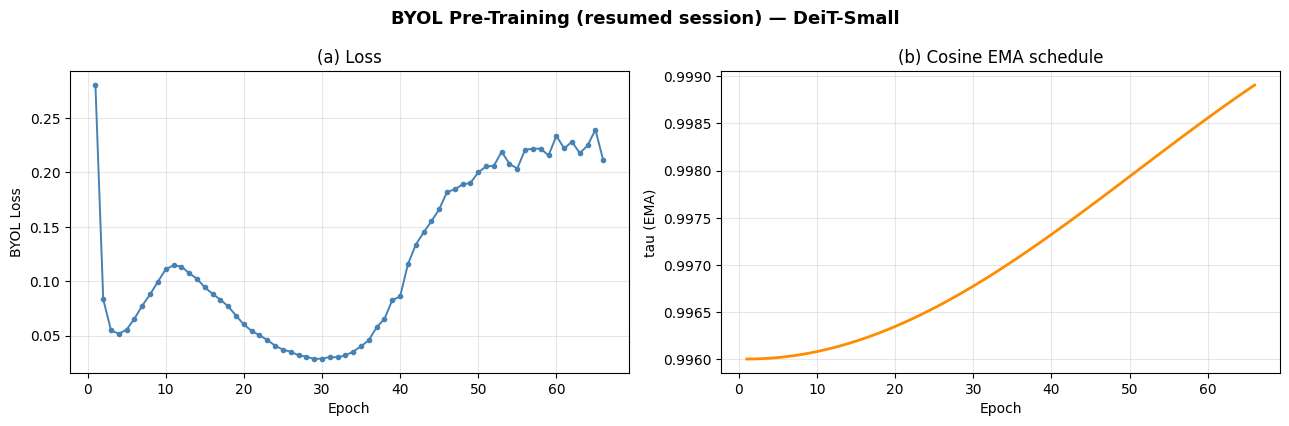

Loss 0.2801 -> 0.2110 over epochs 1-66


In [13]:
if len(ssl_losses) == 0:
    print('No new epochs were trained this session (nothing to plot).')
else:
    x0 = start_epoch + 1
    xs = list(range(x0, x0 + len(ssl_losses)))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
    fig.suptitle('BYOL Pre-Training (resumed session) — DeiT-Small',
                 fontsize=13, fontweight='bold')
    axes[0].plot(xs, ssl_losses, color='steelblue', lw=1.4, marker='o', ms=3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BYOL Loss')
    axes[0].set_title('(a) Loss'); axes[0].grid(alpha=0.3)
    axes[1].plot(xs, tau_history, color='darkorange', lw=2.0)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('tau (EMA)')
    axes[1].set_title('(b) Cosine EMA schedule'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/byol_100ep_training_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Loss {ssl_losses[0]:.4f} -> {ssl_losses[-1]:.4f} over epochs {xs[0]}-{xs[-1]}')

## 8. Linear Probing — primary run (seed 42)

Frozen backbone + single `nn.Linear(384, num_classes)` on the 10% probe set.
This run produces the confusion matrix and per-class report used in the paper;
Section 10 then repeats it across seeds for mean ± std.

In [14]:
class LabelledDs(Dataset):
    def __init__(self, paths, labels, tf): self.paths=paths; self.labels=labels; self.tf=tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB')), self.labels[i]

probe_ds = LabelledDs(paths_probe, lbls_probe, eval_tf)
test_ds  = LabelledDs(paths_test,  lbls_test,  eval_tf)
probe_loader = DataLoader(probe_ds, batch_size=LP_BS, shuffle=True,  num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=LP_BS, shuffle=False, num_workers=8, pin_memory=True)

byol_backbone = _unwrap(online).backbone
byol_backbone.eval()
for p in byol_backbone.parameters(): p.requires_grad_(False)
print(f'Probe: {len(probe_ds)}  Test: {len(test_ds)}  (backbone frozen)')

Probe: 1099  Test: 1099  (backbone frozen)


In [15]:
def train_linear_probe(backbone, seed, epochs=LP_EPOCHS, return_curves=False):
    """Train a fresh linear head on the frozen backbone; return test metrics."""
    set_seed(seed)
    head  = nn.Linear(EMBED_DIM, NUM_CLASSES).to(DEVICE)
    opt   = optim.SGD(head.parameters(), lr=LP_LR, momentum=LP_MOMENTUM)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss()
    loader = DataLoader(probe_ds, batch_size=LP_BS, shuffle=True, num_workers=8,
                        pin_memory=True, generator=torch.Generator().manual_seed(seed))
    tr_loss, te_acc = [], []
    best_acc, best_state = 0., None
    for ep in range(1, epochs + 1):
        head.train(); el = 0.
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            with torch.no_grad(): feats = backbone(imgs)
            loss = crit(head(feats), lbls)
            opt.zero_grad(); loss.backward(); opt.step(); el += loss.item()
        sched.step(); tr_loss.append(el / len(loader))
        head.eval(); c = t = 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                c += (head(backbone(imgs)).argmax(1) == lbls).sum().item(); t += lbls.size(0)
        acc = c / t * 100; te_acc.append(acc)
        if acc > best_acc: best_acc, best_state = acc, copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    # final predictions with best head
    head.eval(); preds, true, probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            logits = head(backbone(imgs.to(DEVICE)))
            probs.append(torch.softmax(logits, 1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy()); true.extend(lbls.numpy())
    preds, true, probs = np.array(preds), np.array(true), np.vstack(probs)
    top1 = (preds == true).mean() * 100
    mf1  = f1_score(true, preds, average='macro')
    pr, rc, _, _ = precision_recall_fscore_support(true, preds, average='macro')
    out = {'top1': top1, 'macro_f1': mf1, 'macro_prec': pr*100, 'macro_rec': rc*100,
           'best_acc': best_acc, 'preds': preds, 'true': true}
    if return_curves: out.update({'tr_loss': tr_loss, 'te_acc': te_acc})
    return out

print('Running primary linear probe (seed 42)...')
lp = train_linear_probe(byol_backbone, 42, return_curves=True)
byol_top1, byol_macro_f1 = lp['top1'], lp['macro_f1']
prec, rec = lp['macro_prec'], lp['macro_rec']
all_preds, all_true = lp['preds'], lp['true']
f1_cls = f1_score(all_true, all_preds, average=None, labels=list(range(NUM_CLASSES)))

print('=' * 56)
print(f'  BYOL Linear Probe (seed 42) — Top-1: {byol_top1:.2f}%')
print(f'  Macro F1: {byol_macro_f1:.4f} | Prec: {prec:.2f}% | Rec: {rec:.2f}%')
print('=' * 56)
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

Running primary linear probe (seed 42)...
  BYOL Linear Probe (seed 42) — Top-1: 82.89%
  Macro F1: 0.8306 | Prec: 83.01% | Rec: 83.17%
                 precision    recall  f1-score   support

     cercospora     0.8075    0.7748    0.7908       222
        healthy     0.7455    0.7455    0.7455       220
mites_and_trips     0.8512    0.8207    0.8357       251
    nutritional     0.7752    0.8325    0.8029       203
 powdery mildew     0.9709    0.9852    0.9780       203

       accuracy                         0.8289      1099
      macro avg     0.8301    0.8317    0.8306      1099
   weighted avg     0.8293    0.8289    0.8288      1099



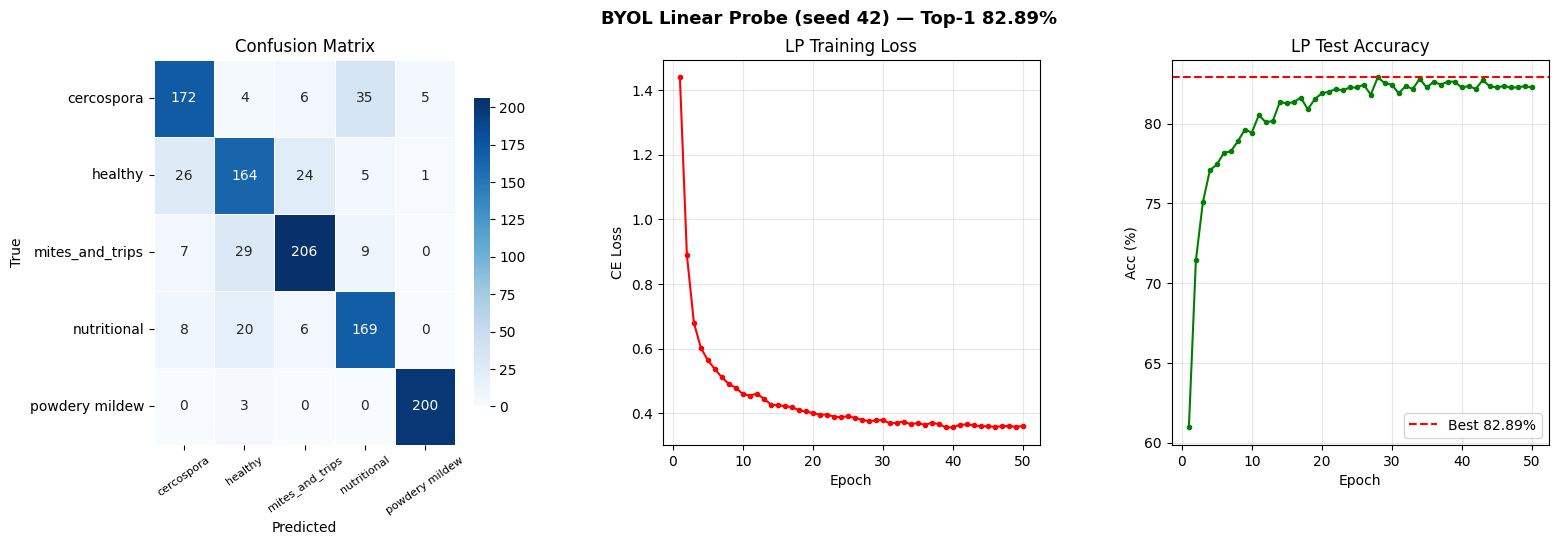

Saved: byol_100ep_lp_results.png


In [16]:
fig = plt.figure(figsize=(18, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.35)
fig.suptitle(f'BYOL Linear Probe (seed 42) — Top-1 {byol_top1:.2f}%',
             fontsize=13, fontweight='bold')

ax = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=short, yticklabels=short, linewidths=0.4, cbar_kws={'shrink':0.8})
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix')
ax.tick_params(axis='x', rotation=35, labelsize=8)

ax = fig.add_subplot(gs[0, 1])
ax.plot(range(1, LP_EPOCHS+1), lp['tr_loss'], 'r-o', ms=3); ax.grid(alpha=0.3)
ax.set_title('LP Training Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('CE Loss')

ax = fig.add_subplot(gs[0, 2])
ax.plot(range(1, LP_EPOCHS+1), lp['te_acc'], 'g-o', ms=3)
ax.axhline(lp['best_acc'], color='red', ls='--', label=f"Best {lp['best_acc']:.2f}%")
ax.set_title('LP Test Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Acc (%)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/byol_100ep_lp_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: byol_100ep_lp_results.png')

## 9. k-NN Evaluation

     k    Accuracy
     1      76.52%
     5      74.52%
    10      73.16%
    20      70.43%
    50      67.88%
   100      63.88%
   200      56.87%
k=20 (comparison table): 70.43%


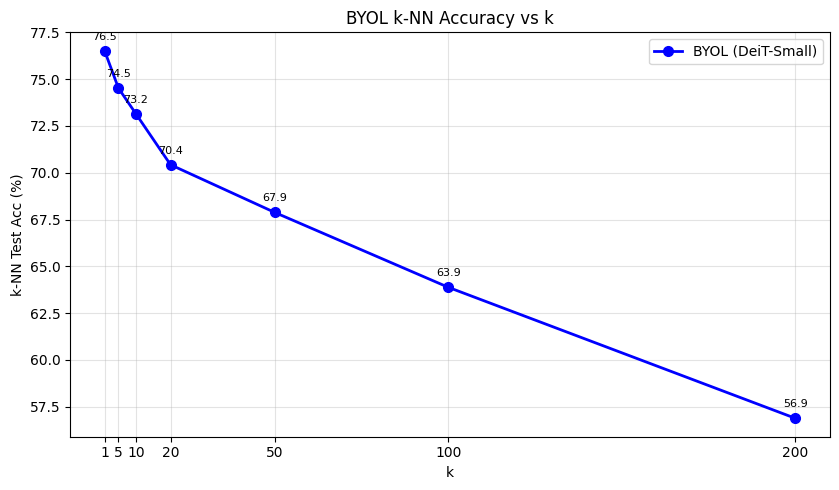

In [17]:
def extract_feats(backbone, loader, desc='Extracting'):
    backbone.eval(); feats, labs = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=desc, leave=False, ncols=80):
            f = F.normalize(backbone(imgs.to(DEVICE)), dim=-1)
            feats.append(f.cpu().numpy()); labs.append(lbls.numpy())
    return np.vstack(feats), np.concatenate(labs)

probe_feats, probe_labs = extract_feats(byol_backbone, probe_loader, 'Probe')
test_feats,  test_labs  = extract_feats(byol_backbone, test_loader,  'Test ')

byol_knn_accs = []
print(f'{"k":>6}  {"Accuracy":>10}')
for k in KNN_KS:
    knn = KNeighborsClassifier(n_neighbors=min(k, len(probe_feats)), metric='cosine', n_jobs=-1)
    knn.fit(probe_feats, probe_labs)
    acc = knn.score(test_feats, test_labs) * 100
    byol_knn_accs.append(acc); print(f'{k:>6}  {acc:>9.2f}%')
byol_knn20 = byol_knn_accs[KNN_KS.index(20)] if 20 in KNN_KS else None
print(f'k=20 (comparison table): {byol_knn20:.2f}%')

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(KNN_KS, byol_knn_accs, 'b-o', ms=7, lw=2, label='BYOL (DeiT-Small)')
ax.set_xlabel('k'); ax.set_ylabel('k-NN Test Acc (%)'); ax.set_xticks(KNN_KS)
ax.set_title('BYOL k-NN Accuracy vs k'); ax.grid(alpha=0.35); ax.legend()
for xi, yi in zip(KNN_KS, byol_knn_accs):
    ax.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/byol_100ep_knn.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Multi-Seed Evaluation — Task 7  (seeds 42, 0, 123)

The expensive SSL backbone is fixed; we re-run the **evaluation stage** (linear
probe head init + probe-set shuffling) under each seed and aggregate. This is the
variance the work-split plan asks for ("multi-seed loop in the eval cells").

> k-NN is deterministic for a fixed backbone and fixed split, so its per-seed
> values are identical (std ≈ 0). Reported for completeness; the meaningful
> variance is in the linear-probe metrics.

In [18]:
per_seed = []
for s in EVAL_SEEDS:
    print(f'\n--- Linear probe @ seed {s} ---')
    r = train_linear_probe(byol_backbone, s)
    print(f'  Top-1={r["top1"]:.2f}%  F1={r["macro_f1"]:.4f}  '
          f'Prec={r["macro_prec"]:.2f}%  Rec={r["macro_rec"]:.2f}%')
    per_seed.append(r)

def agg(key):
    vals = np.array([r[key] for r in per_seed], dtype=float)
    return float(vals.mean()), float(vals.std())

# k-NN(20) per seed (deterministic -> same value, std~0); kept for the table
knn20_seed = []
for s in EVAL_SEEDS:
    set_seed(s)
    knn = KNeighborsClassifier(n_neighbors=min(20, len(probe_feats)), metric='cosine', n_jobs=-1)
    knn.fit(probe_feats, probe_labs)
    knn20_seed.append(knn.score(test_feats, test_labs) * 100)
knn20_mean, knn20_std = float(np.mean(knn20_seed)), float(np.std(knn20_seed))

acc_m, acc_s   = agg('top1')
f1_m,  f1_s    = agg('macro_f1')
pre_m, pre_s   = agg('macro_prec')
rec_m, rec_s   = agg('macro_rec')

print('\n' + '=' * 64)
print('  BYOL MULTI-SEED LINEAR-PROBE SUMMARY  (seeds ' + str(EVAL_SEEDS) + ')')
print('=' * 64)
print(f'  Mean Accuracy   : {acc_m:.2f} %  (std {acc_s:.2f})')
print(f'  Mean Macro-F1   : {f1_m:.4f}    (std {f1_s:.4f})')
print(f'  Mean Precision  : {pre_m:.2f} %  (std {pre_s:.2f})')
print(f'  Mean Recall     : {rec_m:.2f} %  (std {rec_s:.2f})')
print(f'  Mean k-NN(k=20) : {knn20_mean:.2f} %  (std {knn20_std:.2f})')
print('=' * 64)

multiseed = {
    'seeds': EVAL_SEEDS,
    'accuracy' : {'mean': round(acc_m,2), 'std': round(acc_s,2),
                  'per_seed': [round(r['top1'],2) for r in per_seed]},
    'macro_f1' : {'mean': round(f1_m,4), 'std': round(f1_s,4),
                  'per_seed': [round(r['macro_f1'],4) for r in per_seed]},
    'precision': {'mean': round(pre_m,2), 'std': round(pre_s,2)},
    'recall'   : {'mean': round(rec_m,2), 'std': round(rec_s,2)},
    'knn20'    : {'mean': round(knn20_mean,2), 'std': round(knn20_std,2)},
}
with open(f'{OUTPUT_DIR}/byol_100ep_multiseed.json', 'w') as fh:
    json.dump(multiseed, fh, indent=2)
print('Saved: byol_100ep_multiseed.json')


--- Linear probe @ seed 42 ---
  Top-1=82.89%  F1=0.8306  Prec=83.01%  Rec=83.17%

--- Linear probe @ seed 0 ---
  Top-1=82.80%  F1=0.8294  Prec=82.89%  Rec=83.06%

--- Linear probe @ seed 123 ---
  Top-1=82.98%  F1=0.8312  Prec=83.08%  Rec=83.24%

  BYOL MULTI-SEED LINEAR-PROBE SUMMARY  (seeds [42, 0, 123])
  Mean Accuracy   : 82.89 %  (std 0.07)
  Mean Macro-F1   : 0.8304    (std 0.0007)
  Mean Precision  : 82.99 %  (std 0.08)
  Mean Recall     : 83.16 %  (std 0.07)
  Mean k-NN(k=20) : 70.43 %  (std 0.00)
Saved: byol_100ep_multiseed.json


## 11. Save Results (consumed by the DINO comparison cell)

In [19]:
byol_results = {
    'backbone'    : BACKBONE,
    'ssl_epochs'  : _final_epoch,          # true epochs reached this run (scratch/warm/exact-safe)
    'resume_mode' : resumed_mode,
    'lp_top1'     : round(byol_top1, 2),
    'macro_f1'    : round(byol_macro_f1, 4),
    'macro_prec'  : round(prec, 2),
    'macro_rec'   : round(rec, 2),
    'knn_accs'    : {str(k): round(a, 2) for k, a in zip(KNN_KS, byol_knn_accs)},
    'knn20'       : round(byol_knn20, 2) if byol_knn20 is not None else None,
    'multiseed'   : multiseed,
    'per_class_f1': {c: round(float(f1_cls[i]), 4) for i, c in enumerate(CLASS_NAMES)},
}
with open(f'{OUTPUT_DIR}/byol_results.json', 'w') as fh:
    json.dump(byol_results, fh, indent=2)
np.save(f'{OUTPUT_DIR}/byol_knn_accs.npy', np.array(byol_knn_accs))

print('=' * 60)
print('  BYOL_100ep — FINAL SUMMARY')
print('=' * 60)
print(f'  Resume mode     : {resumed_mode}')
print(f'  LP Top-1 (s=42) : {byol_top1:.2f}%')
print(f'  LP Top-1 (mean) : {acc_m:.2f}% +/- {acc_s:.2f}')
print(f'  Macro F1 (mean) : {f1_m:.4f} +/- {f1_s:.4f}')
print(f'  k-NN k=20       : {byol_knn20:.2f}%')
print('=' * 60)
for f in ['byol_backbone.pth', FULL_CKPT_NAME, 'byol_results.json',
          'byol_knn_accs.npy', 'byol_100ep_multiseed.json',
          'byol_100ep_lp_results.png', 'byol_100ep_knn.png']:
    print('  saved:', f)

  BYOL_100ep — FINAL SUMMARY
  Resume mode     : scratch
  LP Top-1 (s=42) : 82.89%
  LP Top-1 (mean) : 82.89% +/- 0.07
  Macro F1 (mean) : 0.8304 +/- 0.0007
  k-NN k=20       : 70.43%
  saved: byol_backbone.pth
  saved: byol_full_checkpoint.pth
  saved: byol_results.json
  saved: byol_knn_accs.npy
  saved: byol_100ep_multiseed.json
  saved: byol_100ep_lp_results.png
  saved: byol_100ep_knn.png


## 12. Notes for the team

- **Backbone init:** timm ImageNet-pretrained DeiT-Small (`pretrained=True`), then BYOL — **not** a custom A01 checkpoint (Aditya Task 1).
- **Resume mode** is printed in Section 5: `exact` if a full checkpoint was attached, `warm` if only `byol_backbone.pth` was found (continues from epoch 63), `scratch` otherwise.
- This notebook now writes `byol_full_checkpoint.pth` every epoch, so re-attaching the working output as an input dataset gives an exact resume next session.
- Hand the saved `byol_*.json` / `.npy` / `.png` files to **Shuvro → Umme** for verification.